In [1]:
from utils import * 
import networkx as nx
import matplotlib.pyplot as plt
import random

In [3]:
n = 3
G1 = nx.DiGraph()
G2 = nx.DiGraph()
V = range(1,n+1)
G1.add_nodes_from(V)
G2.add_nodes_from(V)
E1 = [(2,1),(1,3),(2,3)]
B1 = [(1,2),(1,3),(2,3)]
E2 = [(3,2),(2,1),(3,1)]
B2 = [(1,3), (2,3), (1,2)]
G1.add_edges_from(E1)
G2.add_edges_from(E2)

In [28]:
G1, G2, B1, B2 = find_not_good_pair(N=5000,num_vertex=4,num_confounding=2)

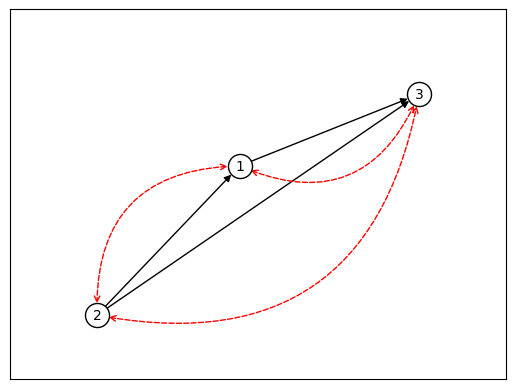

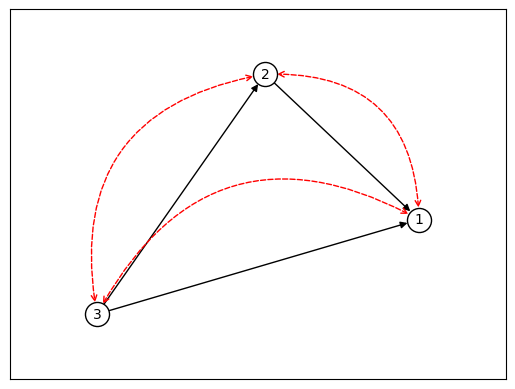

In [37]:
plot_admg(G1,B1)
plot_admg(G2,B2)

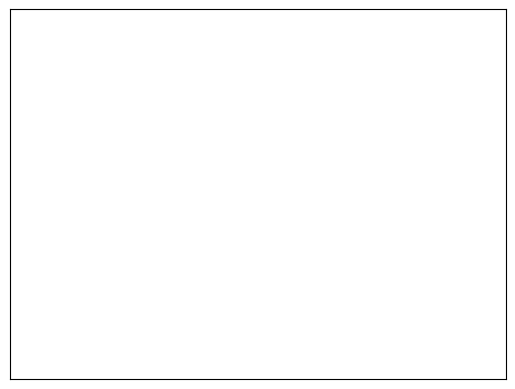

True

In [4]:
plot_auxiliary(G1,G2,B1,B2)

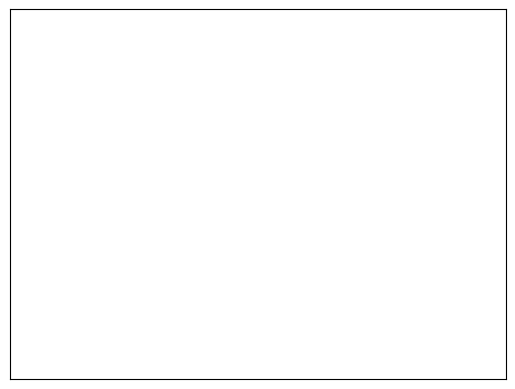

In [39]:
plot_reduced(G1, G2, B1, B2)

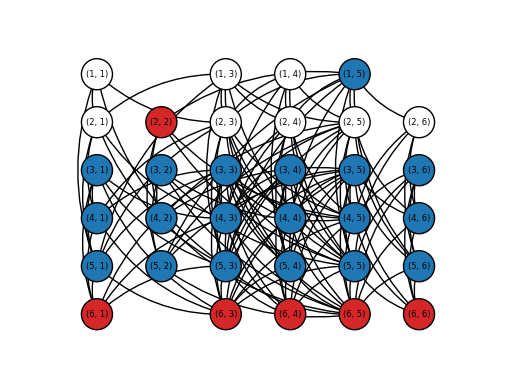

False

In [85]:
num_vertex = 6
num_confounding = 6
G1 = random_dag(num_vertex,random.random())
B1 = random_confounding(num_vertex,num_confounding)
G2 = random_dag(num_vertex,random.random())
B2 = random_confounding(num_vertex,num_confounding)
plot_auxiliary(G1,G2,B1,B2)

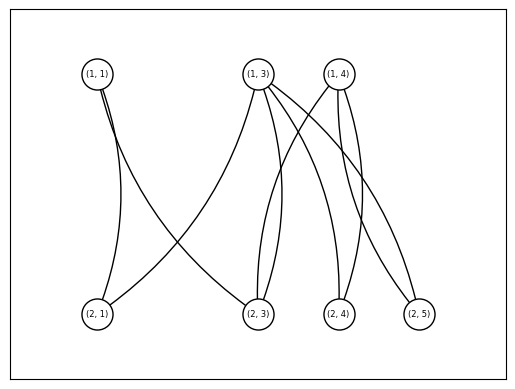

In [90]:
plot_reduced(G1,G2,B1,B2)

In [95]:
V = list(G1.nodes())
V.sort()
IG = induced_graph(V, B1, B2)
IG_cleaned = IG_clean_up(IG, G1, G2, B2)
unremovable = get_removable(V, G1, G2, B2)[1] & IG_cleaned.nodes
unremovable_neighbors = neighbors_of_set(IG_cleaned, unremovable)

remain = IG_cleaned.nodes - unremovable - unremovable_neighbors
IG_remain = IG_cleaned.subgraph(remain).copy()
IG_remain.remove_nodes_from(list(nx.isolates(IG_remain)))

for cover in minimal_vertex_covers_fast(IG_remain):
    print (cover)

{(1, 1), (1, 3), (1, 4)}
{(2, 3), (1, 3), (2, 1), (1, 4)}
{(2, 3), (2, 4), (2, 5), (2, 1)}
{(2, 4), (1, 1), (2, 3), (2, 5), (1, 3)}


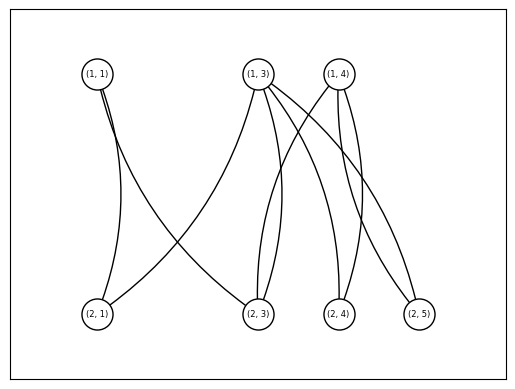

In [ ]:
V = list(G1.nodes())
V.sort()
IG = induced_graph(V, B1, B2)
IG_cleaned = IG_clean_up(IG, G1, G2, B2)
unremovable = get_removable(V, G1, G2, B2)[1] & IG_cleaned.nodes
unremovable_neighbors = neighbors_of_set(IG_cleaned, unremovable)

remain = IG_cleaned.nodes - unremovable - unremovable_neighbors
IG_remain = IG_cleaned.subgraph(remain).copy()
IG_remain.remove_nodes_from(list(nx.isolates(IG_remain)))

i = 1
X = list(get_j(unremovable_neighbors,i)) + [4]
Y = list(G2.predecessors(i))
path_rank(G1, X, Y + [i]) == path_rank(G1, X, Y)


In [3]:
n = 3
G1 = nx.DiGraph()
G2 = nx.DiGraph()
V = range(1,n+1)
G1.add_nodes_from(V)
G2.add_nodes_from(V)
E1 = [(1,2),(2,3)]
B1 = [(2,3)]
E2 = [(1,2),(1,3)]
B2 = [(2,3)]
G1.add_edges_from(E1)
G2.add_edges_from(E2)

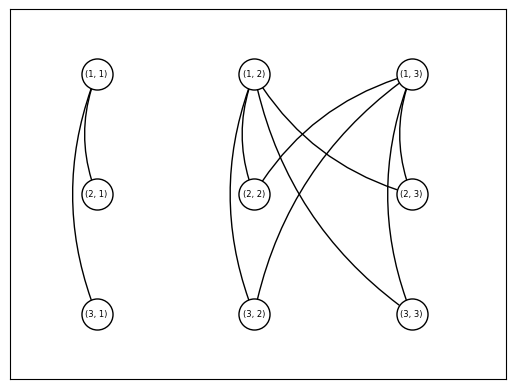

In [9]:
IG = induced_graph(V,B1,B2)
plot_induced(IG)